# Getting started with Beamforming

® *Copyright Bimea 2024-2025*

In this Notebook, we propose to perform beamforming operation on signals comming from a simulated antenna using the `Beamformer` class. 

Dependencies: 
* `pip install pyroomacoustics`

## Generating a source in a free field acoustic environment

Free-field sound propagation between a set of sound sources and a set of microphones can be simulated using the *AnechoicRoom* class of the *Pyroomacoustics* library. It simply consists in setting the maximum image image order of the room simulation to zero:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from megamicros.log import log
from megamicros.core.base import MemsArray
from megamicros.geometry import circle
import pyroomacoustics as pra

log.setLevel( "INFO" ) 

MEMS_NUMBER = 32

# Create the antenna
antenna = MemsArray()
antenna.setAvailableMems( list(range(MEMS_NUMBER)) )
antenna.setSamplingFrequency(16000)

# Set MEMS positions: a circular array of radius 0.175 m
mems_position = np.array( circle( 
    points_number=MEMS_NUMBER, 
    radius=0.175, 
    height=0.0, 
    angle_offset=2 * np.pi / MEMS_NUMBER / 2, 
    clockwise=True ) )

                                             
# Create an anechoic room.
room = pra.AnechoicRoom(fs=16000)

# Attach the antenna to the room.
room.add_microphone_array(mems_position.T.tolist())

# Add a source. We use a white noise signal for the source, and
# the source can be arbitrarily far because there are no walls.
source = np.random.randn(1024)
source_position = [1, 0, -2]
room.add_source(source_position, signal=source)

# run the simulation
signal = room.simulate(return_premix=True)[0,:].T


source.shape:  (1024,)
signal.shape (1214, 32)
signal:  [[ 9.56011753e-10  2.42357554e-08 -2.81143158e-08 ... -1.90923599e-08
  -7.14662158e-08  1.36660864e-08]
 [ 8.84178795e-11 -3.20247443e-08  2.22627072e-09 ... -4.41373646e-08
  -4.48316648e-09 -2.92967243e-08]
 [-1.70714181e-08  8.94448609e-09  6.73592806e-09 ... -1.13504253e-08
   6.25237323e-08 -2.67465539e-08]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -5.13717005e-09
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


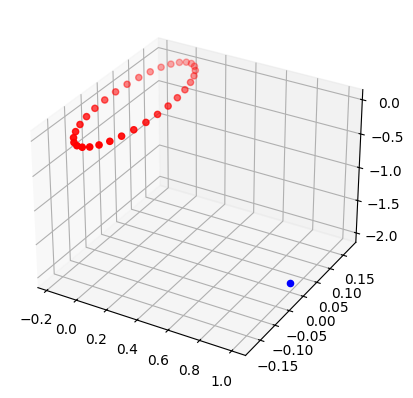

In [2]:
print("source.shape: ", source.shape)
print("signal.shape", signal.shape)
print("signal: ", signal)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mems_position.T[0,:], mems_position.T[1,:], mems_position.T[2,:], c='r', marker='o')
ax.scatter(source_position[0], source_position[1], source_position[2], c='b', marker='o')


## Init the Beamformer

In [3]:
from megamicros.acoustics.bmf import BeamformerFDAS
from megamicros.geometry import horizontalPlan

# Define antenna focal
focal_plan_width = 4.0
focal_plan_depth = 4.0
focal_depth = 2.0
focal_plan_width_sampling = 41
focal_plan_depth_sampling = 41

locations = np.array( horizontalPlan( focal_plan_width, focal_plan_depth, focal_depth, focal_plan_width_sampling, focal_plan_depth_sampling ) )

# Create the beamformer
bmf = BeamformerFDAS( 
    mems_position = mems_position,
    locations = locations,
    sampling_frequency = antenna.sampling_frequency,
    frame_length = antenna.frame_length,
)

2025-11-15 21:49:26,162 [INFO]:  .Set beamformer on a 32 MEMs antenna
2025-11-15 21:49:26,163 [INFO]:  .Set beamformer sampling frequency to 16000 Hz
2025-11-15 21:49:26,163 [INFO]:  .Set 1681 beamforming locations
2025-11-15 21:49:26,164 [INFO]:  .Set beamformer frame length to 1024 Samples
2025-11-15 21:49:26,164 [INFO]:  .Set beamformer FFT window size to 1024 samples
2025-11-15 21:49:26,165 [INFO]:  .BeamformerFDAS Initilization:
2025-11-15 21:49:26,165 [INFO]:   > Found antenna with 32 MEMs microphones
2025-11-15 21:49:26,165 [INFO]:   > FFT window size is 1024 samples
2025-11-15 21:49:26,166 [INFO]:   > Time range: [0, 0.0639375] s
2025-11-15 21:49:26,166 [INFO]:   > Sampling frequency: 16000 Hz
2025-11-15 21:49:26,167 [INFO]:   > Frequency range: [0, 8000.0] Hz (513 beams)
2025-11-15 21:49:26,168 [INFO]:   > frequency step: 15.59 Hz
2025-11-15 21:49:26,168 [INFO]:   > frequency bandwidth: [0.00, 8000.00] Hz
2025-11-15 21:49:26,169 [INFO]:   > frequency bandwidth indexes: [0, 512

Compute the BFE

In [4]:
BFE, _, _ = bmf.compute( signal )
image = BFE.reshape( ( focal_plan_depth_sampling, focal_plan_width_sampling ) )

2025-11-15 21:49:29,156 [WARNING]: in megamicros.log (bmf.py:335):  .bmf > Input signal is longer than FFT width: it will be truncated


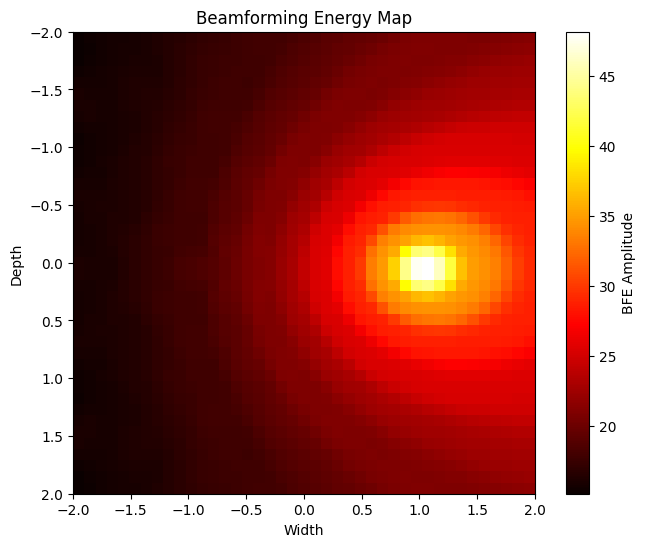

In [5]:
# Calculate the extent of the focal plane in meters
width_extent = [-focal_plan_width/2, focal_plan_width/2]
depth_extent = [-focal_plan_depth/2, focal_plan_depth/2]

# Display the beamforming energy map on the focal plane
plt.figure(figsize=(8, 6))
plt.imshow(
    image, cmap='hot', 
    interpolation='nearest', 
    extent=[width_extent[0], 
        width_extent[1], 
        depth_extent[1], 
        depth_extent[0]
    ]
)
plt.colorbar(label='BFE Amplitude')
plt.title('Beamforming Energy Map')
plt.xlabel('Width')
plt.ylabel('Depth')
plt.show()

In [6]:
# Store the 3D locations in a json file
import json

print("locations.shape: ", locations.shape)
with open("locations.json", "w") as f:
    json.dump(locations.tolist(), f)
#!/usr/bin/env python3

# Store 3D MEMS positions in a json file
with open("mems_positions.json", "w") as f:
    json.dump(mems_position.tolist(), f)


# Transform the signal into a 1D vector of values interleaved per MEMS
# (e.g., [mems1_sample1, mems2_sample1, ..., memsN_sample1, mems1_sample2, ...])
# and store it in a json file
# Flatten the signal array in C order (row-major) to achieve interleaving
signal_flat = signal.flatten(order='C')
print(signal_flat.shape)
print(signal_flat[:10])  # Print first 10 samples for verification

# Store the signal in a json file
with open("signal.json", "w") as f:
    json.dump(signal_flat.tolist(), f)


locations.shape:  (1681, 3)
(38848,)
[ 9.56011753e-10  2.42357554e-08 -2.81143158e-08 -1.27767901e-08
 -3.73431741e-10  1.49288989e-09  7.48174490e-08  1.54781759e-08
  1.54781759e-08  7.48174490e-08]


In [7]:
print("locations.shape: ", locations.shape)
print("BFE.shape: ", BFE.shape)
print("image.shape: ", image.shape)

locations.shape:  (1681, 3)
BFE.shape:  (1681,)
image.shape:  (41, 41)
